In [1]:
# ======================================================
# 0. ライブラリの読み込み & 描画スタイル設定
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)          # 好みで調整
pd.set_option("display.max_columns", None)          # 全列表示

In [2]:
# ======================================================
# 1. データ読み込み
# ======================================================
train = pd.read_csv("playground-series-s5e5/train.csv")
test  = pd.read_csv("playground-series-s5e5/test.csv")

display(train.head())          # 先頭5行
print("\nShape:", train.shape) # 行数・列数


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0



Shape: (750000, 9)


In [3]:
# ======================================================
# 2. 基本統計量と概要
# ======================================================
train.info()      # データ型・欠損の有無
display(train.describe().T)   # 数値列の統計量（平均・分散など）

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
Age,750000.0,41.420404,15.175049,20.0,28.00,40.0,52.00,79.0
Height,750000.0,174.697685,12.824496,126.0,164.00,174.0,185.00,222.0
Weight,750000.0,75.145668,13.982704,36.0,63.00,74.0,87.00,132.0
Duration,750000.0,15.421015,8.354095,1.0,8.00,15.0,23.00,30.0
Heart_Rate,750000.0,95.483995,9.449845,67.0,88.00,95.0,103.00,128.0
Body_Temp,750000.0,40.036253,0.779875,37.1,39.60,40.3,40.70,41.5
Calories,750000.0,88.282781,62.395349,1.0,34.00,77.0,136.00,314.0


In [4]:
# ======================================================
# 3. 欠損値の確認
# ======================================================
missing = train.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
display(missing[missing > 0])

Missing values per column:


Series([], dtype: int64)

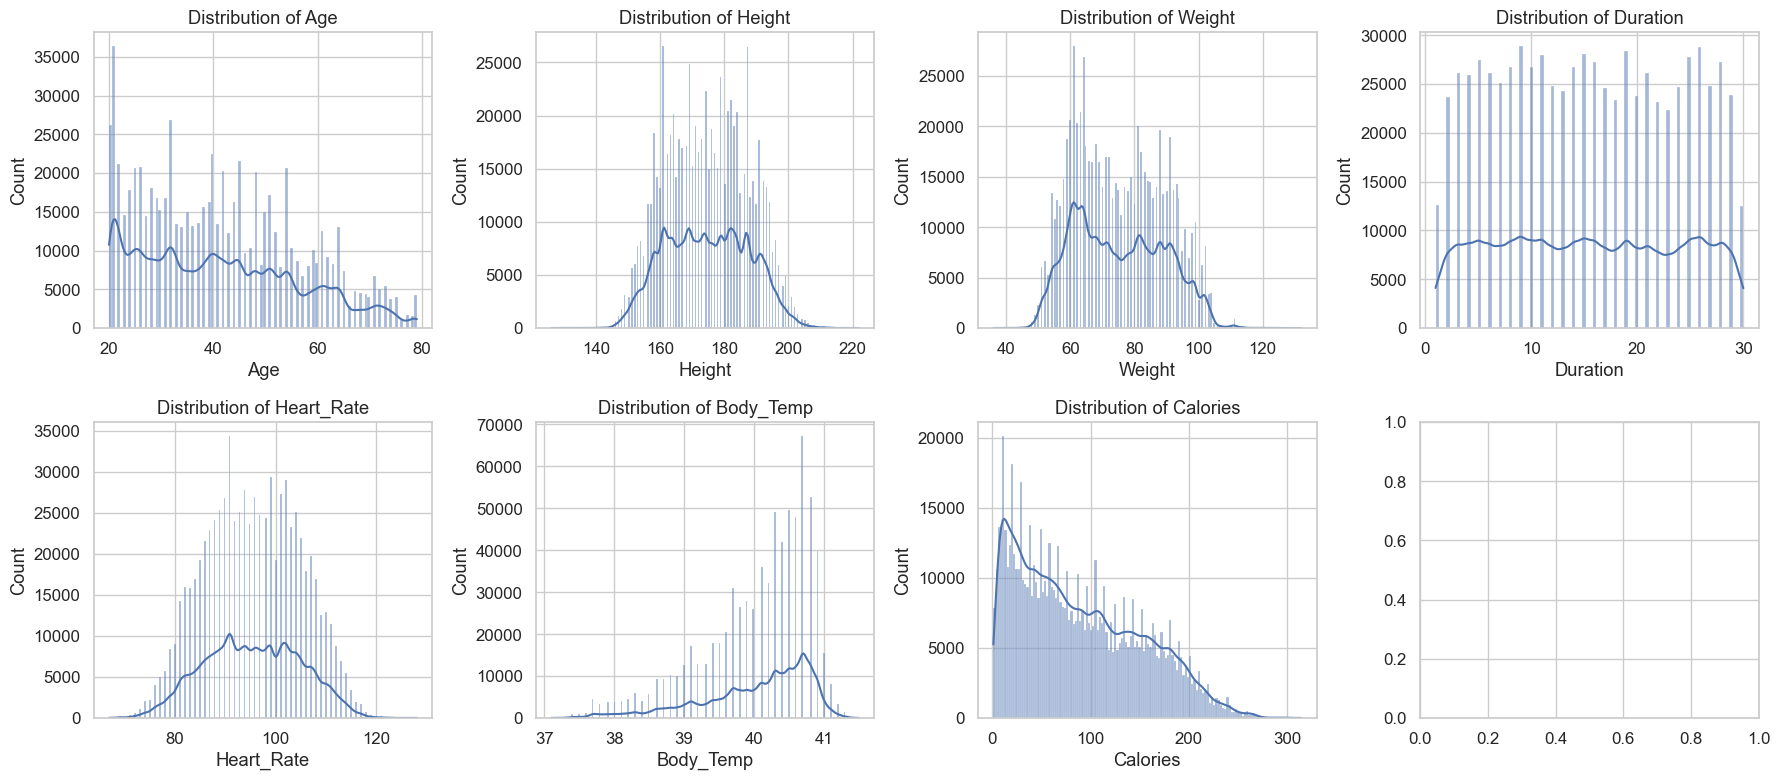

In [5]:
# ======================================================
# 4. 数値変数の分布（ヒストグラム）
# ======================================================
num_cols = ["Age", "Height", "Weight", "Duration", "Heart_Rate",
            "Body_Temp", "Calories"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()

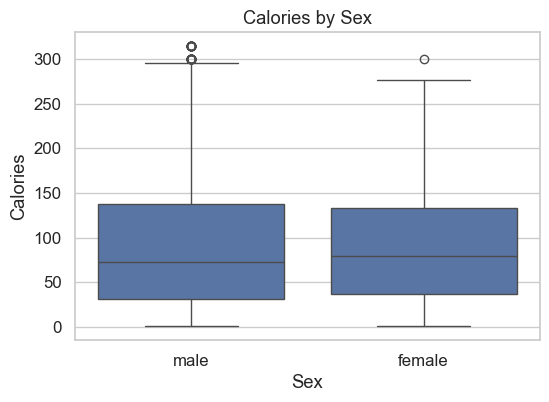

In [6]:
# ======================================================
# 5. カテゴリ変数 × 数値目標の関係
#    （例: Sex ごとの Calories 分布を箱ひげ図で）
# ======================================================
plt.figure(figsize=(6, 4))
sns.boxplot(data=train, x="Sex", y="Calories")
plt.title("Calories by Sex")
plt.show()

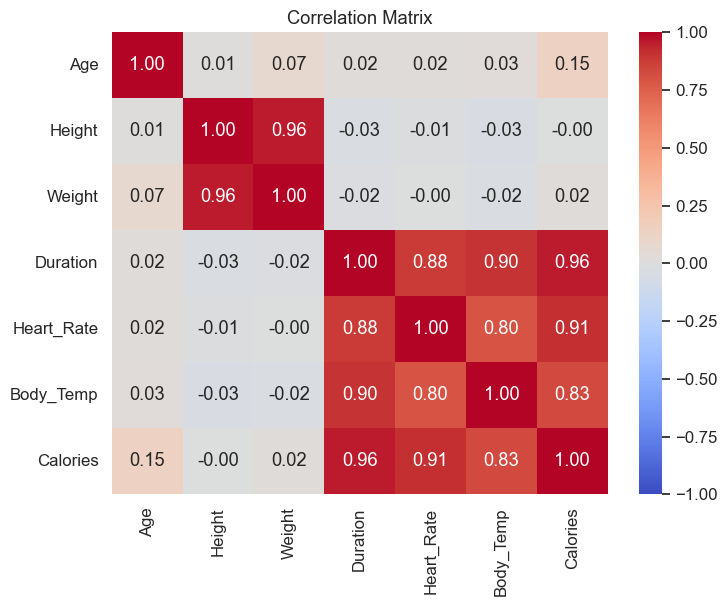

In [7]:
# ======================================================
# 6. 数値変数の相関ヒートマップ
# ======================================================
corr = train[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

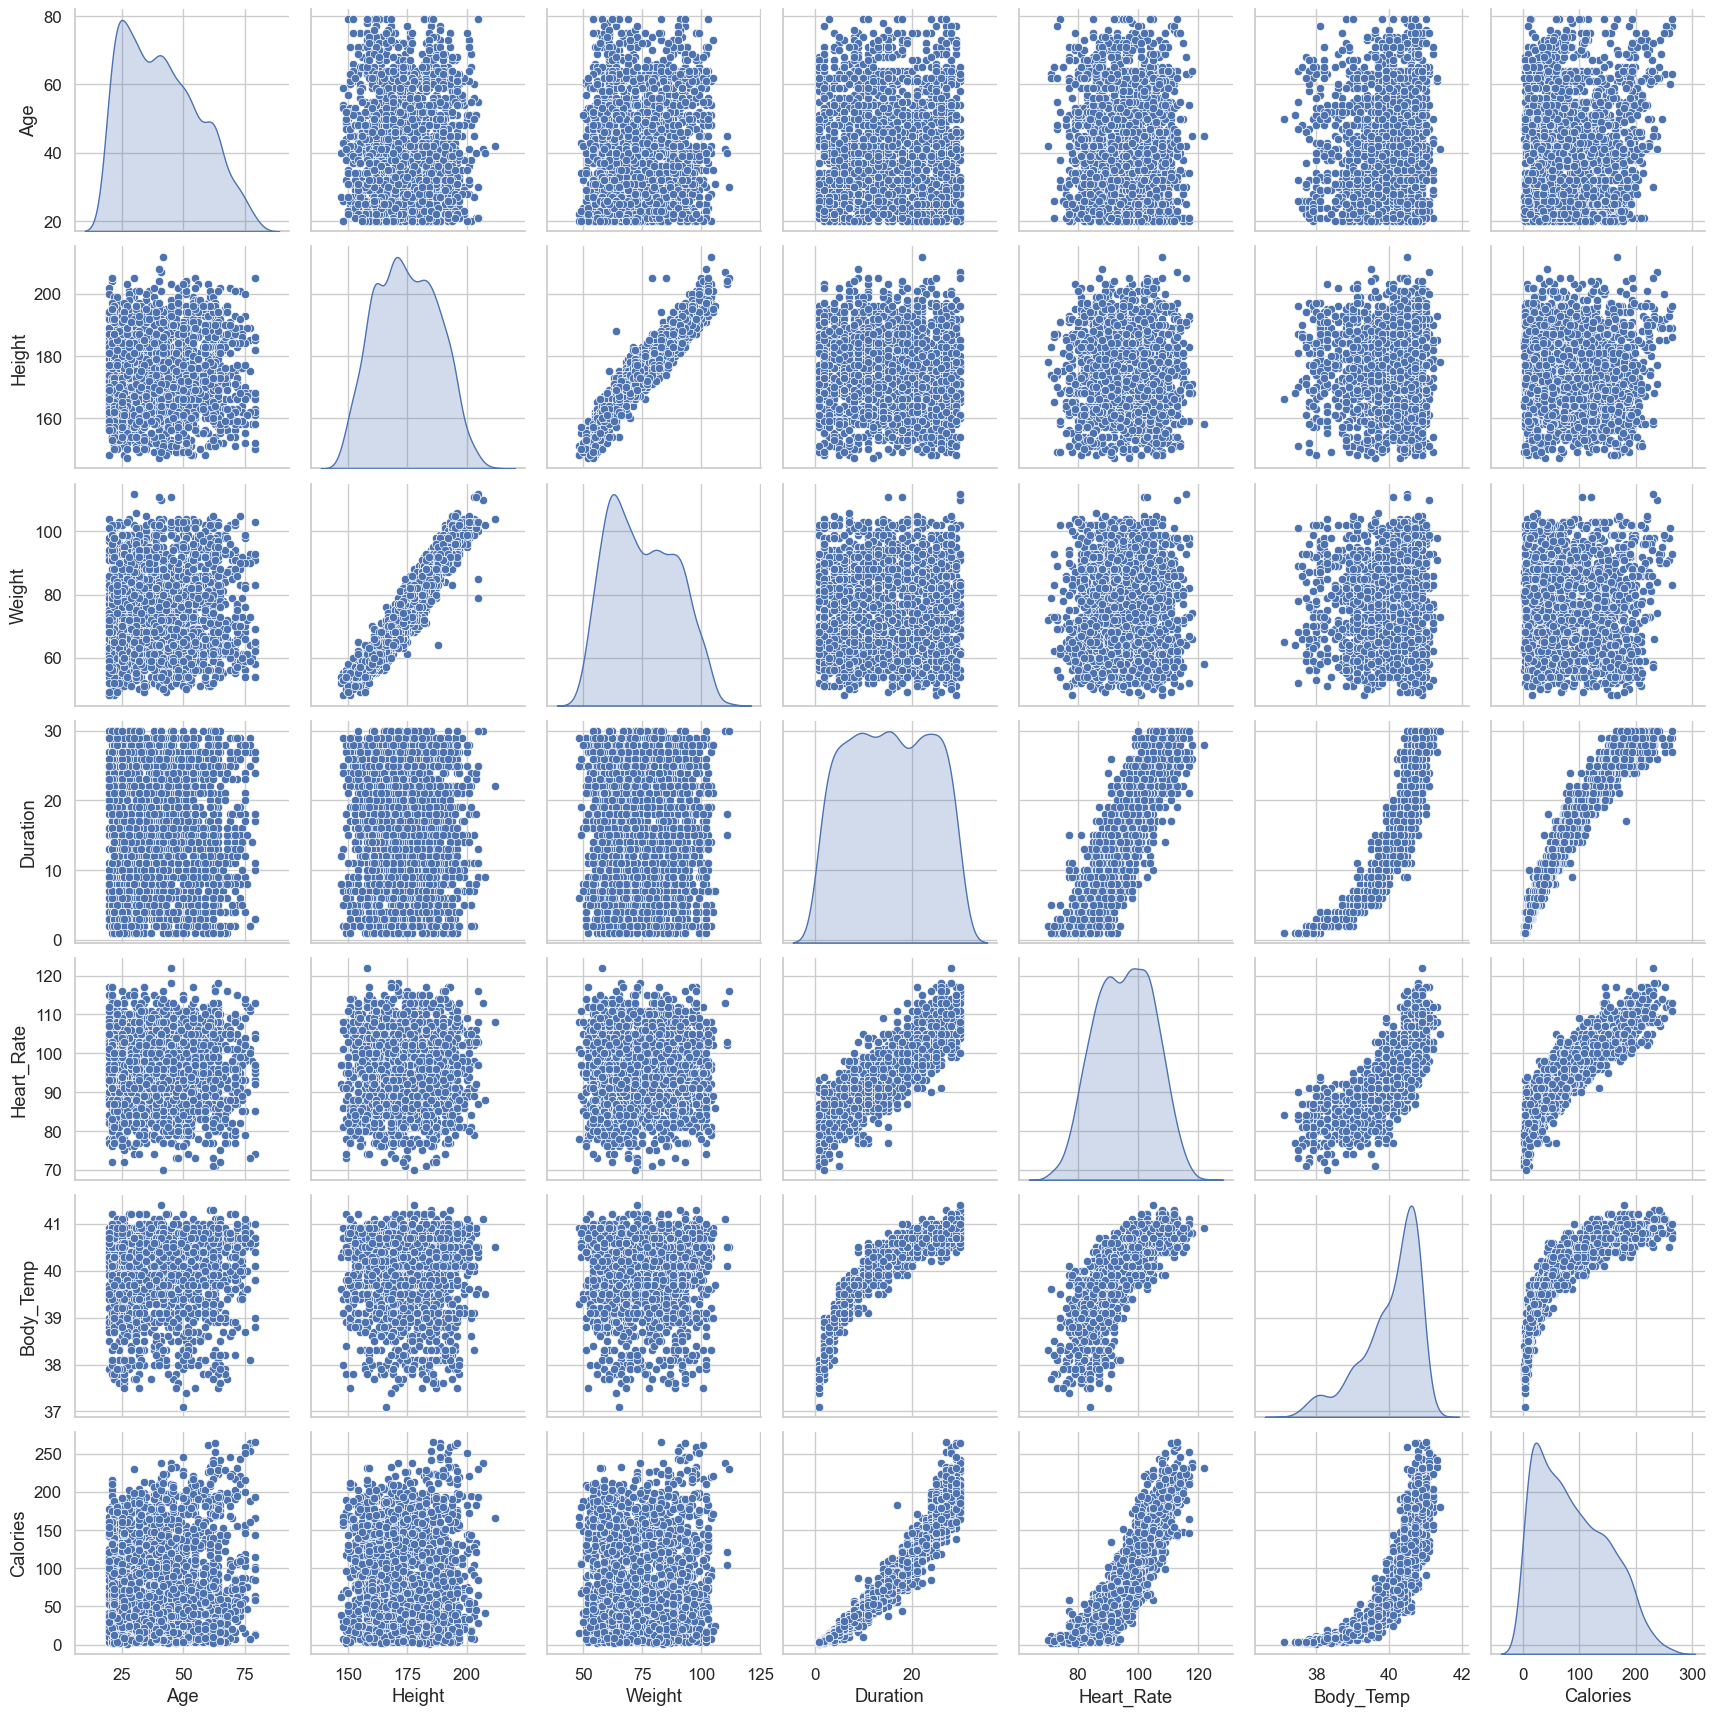

In [8]:
# ======================================================
# 7. ペアプロット（主要変数間の散布図と分布）
#    * 大規模データの場合はサンプルを抽出して可視化
# ======================================================
sample = train.sample(n=2000, random_state=42)   # 適宜サイズ調整
sns.pairplot(sample[num_cols], diag_kind="kde")
plt.show()

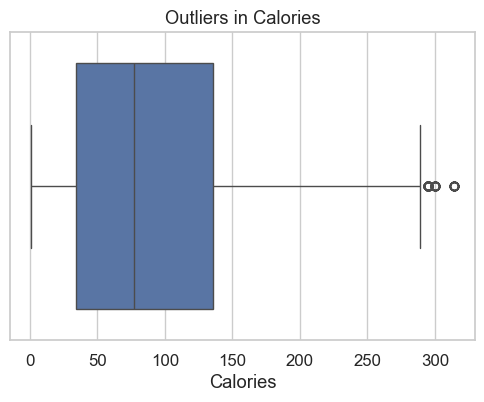

In [9]:
# ======================================================
# 8. 外れ値の確認（例: Calories)
# ======================================================
plt.figure(figsize=(6, 4))
sns.boxplot(x=train["Calories"])
plt.title("Outliers in Calories")
plt.show()

In [10]:
# ======================================================
# 9. グループ統計例
# ======================================================
group_stats = (
    train
    .groupby("Sex")                            # 例: Sex ごと
    .agg(
        mean_calories=("Calories", "mean"),
        median_calories=("Calories", "median"),
        count=("Calories", "size")
    )
    .reset_index()
)
display(group_stats)

,Sex,mean_calories,median_calories,count
0,female,87.534761,80.0,375721
1,male,89.033683,73.0,374279


In [11]:
# =========================================================
# 0. ライブラリ
# =========================================================
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# 1. データ読み込み & id を削除
# =========================================================

y     = train["Calories"]          # 目的変数
X     = train.drop(columns=["Calories", "id"])
X_test = test.drop(columns=["id"])

# ---------------------------------------------------------
# 2. カスタム特徴量生成クラス
# ---------------------------------------------------------
class CustomFeatureGenerator(BaseEstimator, TransformerMixin):
    """BMI や掛け合わせなどを DataFrame に直接追加する"""
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_ = X.copy()
        # --- BMI ---
        X_["BMI"] = X_["Weight"] / ((X_["Height"] / 100.0) ** 2)
        # --- 運動強度 Proxy ---
        X_["HRxDur"]    = X_["Heart_Rate"] * X_["Duration"]
        X_["TempDiffxDur"] = (X_["Body_Temp"] - 37.0) * X_["Duration"]
        # --- 年齢×心拍 ---
        X_["AgeHR"] = X_["Age"] * X_["Heart_Rate"]
        return X_



In [12]:
# ---------------------------------------------------------
# 3. 列ごとの前処理
# ---------------------------------------------------------
num_cols = ["Age", "Height", "Weight", "Duration",
            "Heart_Rate", "Body_Temp",
            "BMI", "HRxDur", "TempDiffxDur", "AgeHR"]  # ← CustomFeatureGenerator で追加される列もここに書く
cat_cols = ["Sex"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())          # ツリー系で不要ならコメントアウト可
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first"))   # 0/1 のダミー1列に
])

preproc = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

preproc

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Height', 'Weight', 'Duration',
                                  'Heart_Rate', 'Body_Temp', 'BMI', 'HRxDur',
                                  'TempDiffxDur', 'AgeHR']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'))]),
                                 ['Sex'])])

In [13]:
# ---------------------------------------------------------
# 4. 重要度で特徴量選択 (オプション)
# ---------------------------------------------------------

import time

pipe = Pipeline([
    ("feat_gen", CustomFeatureGenerator()),
    ("preproc",  preproc),
])

# 1. 前処理
start = time.time()
X_processed = pipe.fit_transform(X, y)
print(f"[1] 前処理完了 - {X_processed.shape[1]}列 - {time.time() - start:.2f}秒")

# 2. 特徴量選択モデル定義
selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42),
    threshold="median"
)

# 3. 特徴量選択（ここが重い）
start = time.time()
selector.fit(X_processed, y)
print(f"[2] SelectFromModel fit 完了 - {time.time() - start:.2f}秒")

# 4. 変換
X_selected = selector.transform(X_processed)
print(f"[3] 選ばれた特徴量数: {X_selected.shape[1]} / {X_processed.shape[1]}")

[1] 前処理完了 - 11列 - 1.30秒
[2] SelectFromModel fit 完了 - 475.28秒
[3] 選ばれた特徴量数: 6 / 11


In [14]:
# ---------------------------------------------------------
# 5. 最終パイプライン（例：RandomForest で学習）
#    * ここは XGBRegressor / LGBMRegressor などに差し替えても OK
# ---------------------------------------------------------
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

pipe = Pipeline([
    ("feat_gen", CustomFeatureGenerator()),
    ("preproc",  preproc),
    ("select",   selector),    # ← 要らなければ削除
    ("model",    model)
])


In [15]:
# =========================================================
# 6. 学習 & 推論
# =========================================================
pipe.fit(X, y)

preds = pipe.predict(X_test)



In [16]:
# ---------------------------------------------------------
# 7. 提出ファイル作成
# ---------------------------------------------------------
submission = pd.DataFrame({
    "id": test["id"],
    "Calories": preds
})
submission.to_csv("submission.csv", index=False)

In [19]:
submission.head()

,id,Calories
0,750000,27.4000
1,750001,107.7800
2,750002,86.1600
3,750003,126.0800
4,750004,75.8765


In [22]:
import joblib

# 学習済みの pipe を保存
joblib.dump(pipe, "trained_pipe.joblib")


['trained_pipe.joblib']

In [ ]:
# # モデルの読み込み
# pipe_loaded = joblib.load("trained_pipe.joblib")

# # 新しいデータ（DataFrame）に対して推論
# new_data = pd.read_csv("new_input.csv")  # 例：新しいCSVから読み込む
# new_preds = pipe_loaded.predict(new_data)